# 01 - Prétraitement des données

Ce notebook détaille le chargement, le filtrage et la préparation des données des capteurs mobiles pour l'entraînement du modèle.
Tous les prétraitements sont implémentés inline avec visualisations.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, lfilter

# Configuration matplotlib
%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')

## 1. Définition des fonctions de preprocessing

Implémentation inline des fonctions de filtrage et windowing.

In [2]:
def butter_lowpass(cutoff, fs, order=4):
    """Design a Butterworth low-pass filter."""
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return b, a

def apply_filter(data, cutoff=10.0, fs=50.0):
    """Apply a Butterworth low-pass filter to the data."""
    b, a = butter_lowpass(cutoff, fs)
    return lfilter(b, a, data, axis=0)

def create_windows(data, labels, window_size=100, step=50):
    """Create rolling windows from the data."""
    X, y = [], []
    for start in range(0, len(data) - window_size, step):
        end = start + window_size
        X.append(data[start:end])
        # Case where labels might be provided as a sequence
        if isinstance(labels, (list, np.ndarray)) and len(labels) == len(data):
            window_labels = labels[start:end]
            y.append(np.bincount(window_labels).argmax())
        else:
            # Case where labels is a single value for the whole sequence
            y.append(labels)
    return np.array(X), np.array(y)

def load_sensor_data(sample_folder):
    """Load Accelerometer and Gyroscope data from a specific sample folder."""
    accel_path = os.path.join(sample_folder, 'Accelerometer.csv')
    gyro_path = os.path.join(sample_folder, 'Gyroscope.csv')
    
    accel_df = pd.read_csv(accel_path)
    gyro_df = pd.read_csv(gyro_path)
    
    min_len = min(len(accel_df), len(gyro_df))
    
    # Structure: [accel_x, accel_y, accel_z, gyro_x, gyro_y, gyro_z]
    data = np.zeros((min_len, 6))
    data[:, 0:3] = accel_df[['x', 'y', 'z']].values[:min_len]
    data[:, 3:6] = gyro_df[['x', 'y', 'z']].values[:min_len]
    
    return data

def load_dataset(base_path):
    """Iterate through the data structure and load all samples."""
    X_all, y_all = [], []
    classes = {'perfect': 1, 'imperfect': 0}
    
    for class_name, class_idx in classes.items():
        class_folder = os.path.join(base_path, class_name)
        if not os.path.exists(class_folder):
            continue
            
        sample_folders = sorted([f for f in os.listdir(class_folder) 
                                if os.path.isdir(os.path.join(class_folder, f))])
        
        for sample_folder in sample_folders:
            path = os.path.join(class_folder, sample_folder)
            data = load_sensor_data(path)
            
            # Preprocessing: Filter
            data_filtered = np.zeros_like(data)
            for i in range(6):
                data_filtered[:, i] = apply_filter(data[:, i])
                
            # Windowing
            X_win, y_win = create_windows(data_filtered, class_idx)
            
            if len(X_win) > 0:
                X_all.append(X_win)
                y_all.append(y_win)
                
    if not X_all:
        return np.array([]), np.array([])
        
    return np.concatenate(X_all), np.concatenate(y_all)

print("✓ Fonctions de preprocessing définies")

✓ Fonctions de preprocessing définies


## 2. Visualisation du filtrage

Démonstration de l'effet du filtre Butterworth sur un signal brut.

Données brutes chargées: (307, 6)


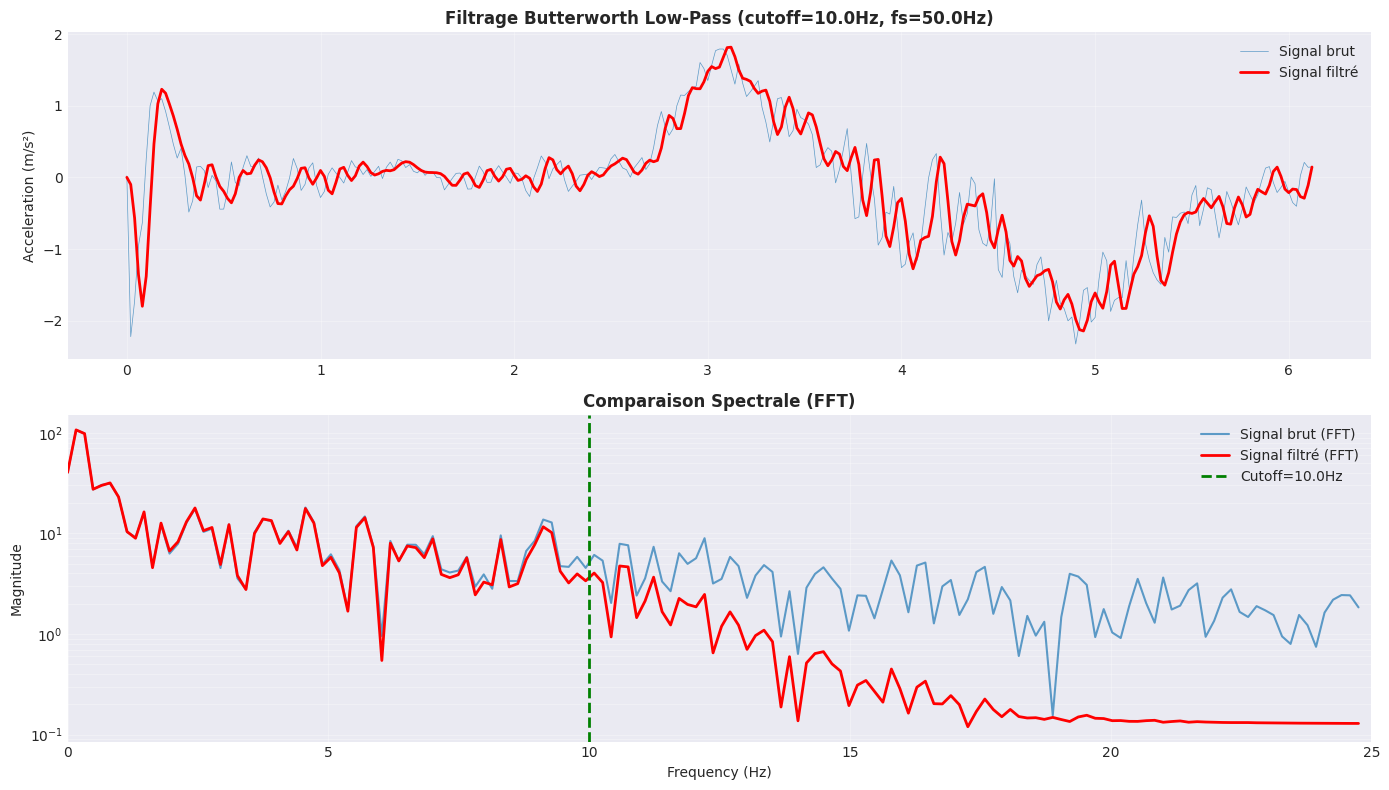


Signal brut - Mean: -0.1307, Std: 0.7963
Signal filtré - Mean: -0.1319, Std: 0.7804


In [3]:
# Charger un échantillon pour démonstration du filtrage
sample_perfect = '../data/perfect/2026-04-19_09-55-28'

if os.path.exists(sample_perfect):
    raw_data = load_sensor_data(sample_perfect)
    print(f"Données brutes chargées: {raw_data.shape}")
    
    # Appliquer le filtre sur l'axe x de l'accéléromètre
    cutoff = 10.0  # Hz
    fs = 50.0  # Hz (sampling frequency)
    
    raw_accel_x = raw_data[:, 0]
    filtered_accel_x = apply_filter(raw_accel_x, cutoff=cutoff, fs=fs)
    
    # Visualisation avant/après filtrage
    fig, ax = plt.subplots(2, 1, figsize=(14, 8))
    
    time_samples = np.arange(len(raw_accel_x)) / fs
    
    ax[0].plot(time_samples, raw_accel_x, label='Signal brut', alpha=0.7, linewidth=0.5)
    ax[0].plot(time_samples, filtered_accel_x, label='Signal filtré', linewidth=2, color='red')
    ax[0].set_title(f"Filtrage Butterworth Low-Pass (cutoff={cutoff}Hz, fs={fs}Hz)", fontsize=12, fontweight='bold')
    ax[0].set_ylabel("Acceleration (m/s²)")
    ax[0].legend(loc='upper right')
    ax[0].grid(True, alpha=0.3)
    
    # FFT comparison
    from numpy.fft import fft, fftfreq
    N = len(raw_accel_x)
    freq = fftfreq(N, d=1/fs)[:N//2]
    raw_fft = np.abs(fft(raw_accel_x))[:N//2]
    filtered_fft = np.abs(fft(filtered_accel_x))[:N//2]
    
    ax[1].semilogy(freq, raw_fft, label='Signal brut (FFT)', alpha=0.7)
    ax[1].semilogy(freq, filtered_fft, label='Signal filtré (FFT)', linewidth=2, color='red')
    ax[1].axvline(cutoff, color='green', linestyle='--', label=f'Cutoff={cutoff}Hz', linewidth=2)
    ax[1].set_title("Comparaison Spectrale (FFT)", fontsize=12, fontweight='bold')
    ax[1].set_xlabel("Frequency (Hz)")
    ax[1].set_ylabel("Magnitude")
    ax[1].legend()
    ax[1].grid(True, alpha=0.3, which='both')
    ax[1].set_xlim([0, 25])
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nSignal brut - Mean: {raw_accel_x.mean():.4f}, Std: {raw_accel_x.std():.4f}")
    print(f"Signal filtré - Mean: {filtered_accel_x.mean():.4f}, Std: {filtered_accel_x.std():.4f}")
else:
    print(f"⚠ Répertoire {sample_perfect} non trouvé")

## 3. Visualisation du Windowing

Démonstration de la création de fenêtres temporelles chevauchantes.

Signal original: (307, 6)
Signal filtré: (307, 6)
Nombre de fenêtres créées: 5
Forme de chaque fenêtre: (100, 6) (seq_len, channels)


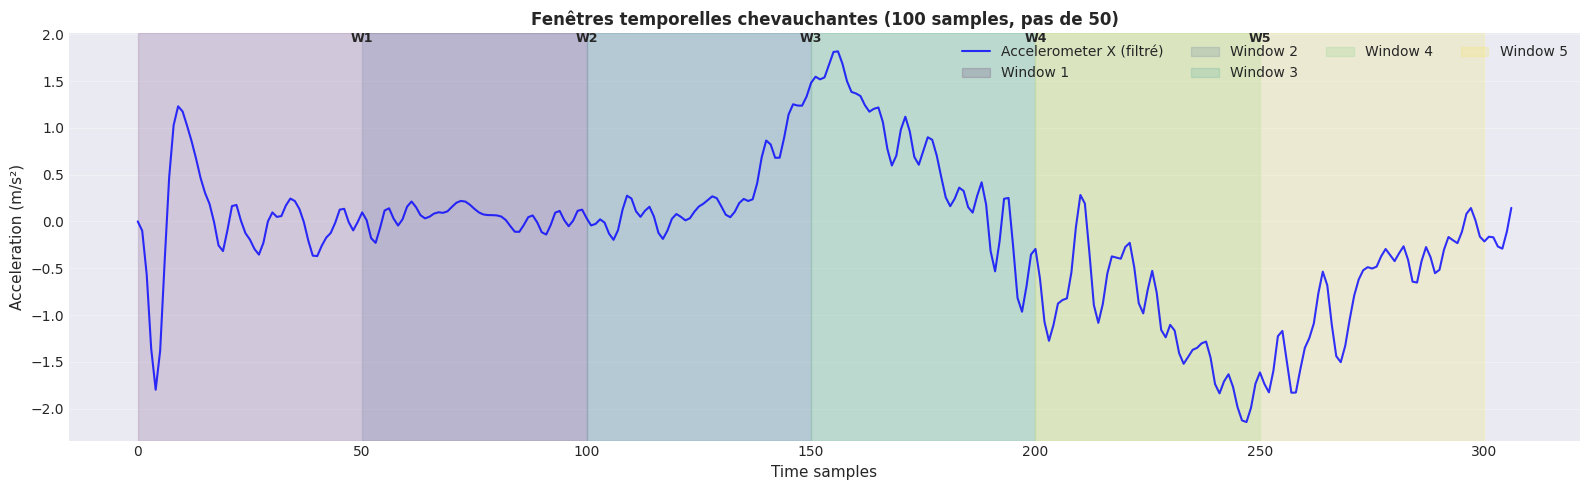


Chevauchement: 50 samples (50%)
Durée par fenêtre: 2.00 secondes


In [4]:
# Utiliser les mêmes données
if os.path.exists(sample_perfect):
    raw_data = load_sensor_data(sample_perfect)
    
    # Appliquer le filtrage sur tous les capteurs
    data_filtered = np.zeros_like(raw_data)
    for i in range(6):
        data_filtered[:, i] = apply_filter(raw_data[:, i])
    
    # Créer les fenêtres
    X_windows, y_windows = create_windows(data_filtered, labels=1, window_size=100, step=50)
    
    print(f"Signal original: {raw_data.shape}")
    print(f"Signal filtré: {data_filtered.shape}")
    print(f"Nombre de fenêtres créées: {len(X_windows)}")
    print(f"Forme de chaque fenêtre: {X_windows[0].shape} (seq_len, channels)")
    
    # Visualisation des fenêtres chevauchantes
    fig, ax = plt.subplots(figsize=(16, 5))
    
    # Plot l'accéléromètre X
    ax.plot(data_filtered[:, 0], linewidth=1.5, label='Accelerometer X (filtré)', color='blue', alpha=0.8)
    
    # Colorer les fenêtres
    window_size = 100
    step = 50
    colors = plt.cm.viridis(np.linspace(0, 1, min(6, len(X_windows))))
    
    for i in range(min(6, len(X_windows))):
        start = i * step
        end = start + window_size
        ax.axvspan(start, end, alpha=0.15, color=colors[i], label=f'Window {i+1}')
        # Marquer le centre
        center = (start + end) / 2
        ax.text(center, ax.get_ylim()[1]*0.95, f'W{i+1}', ha='center', fontsize=9, fontweight='bold')
    
    ax.set_xlabel("Time samples", fontsize=11)
    ax.set_ylabel("Acceleration (m/s²)", fontsize=11)
    ax.set_title("Fenêtres temporelles chevauchantes (100 samples, pas de 50)", fontsize=12, fontweight='bold')
    ax.legend(loc='upper right', ncol=4)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print(f"\nChevauchement: {window_size - step} samples (50%)")
    print(f"Durée par fenêtre: {window_size / fs:.2f} secondes")

## 4. Chargement du dataset complet

Chargement de tous les échantillons avec tous les prétraitements.

In [5]:
print("Chargement du dataset complet...")
base_path = '../data'
X, y = load_dataset(base_path)

print(f"\n✓ Dataset chargé et prétraité:")
print(f"  X shape: {X.shape} (batch, seq_len, channels)")
print(f"  y shape: {y.shape}")
print(f"  Distribution des classes: {np.bincount(y.astype(int))} (Imperfect=0, Perfect=1)")
print(f"  Total d'échantillons: {len(X)}")

Chargement du dataset complet...

✓ Dataset chargé et prétraité:
  X shape: (125, 100, 6) (batch, seq_len, channels)
  y shape: (125,)
  Distribution des classes: [39 86] (Imperfect=0, Perfect=1)
  Total d'échantillons: 125


## 5. Transposition et Normalisation

Préparation finale du format PyTorch.

In [6]:
# Transpose to (batch, channels, seq_len) for Conv1D
X = np.transpose(X, (0, 2, 1))
print(f"Après transposition: {X.shape} (batch, channels, seq_len)")
print(f"Canaux: [accel_x, accel_y, accel_z, gyro_x, gyro_y, gyro_z]")

# Normalization
mean = X.mean(axis=(0, 2))
std = X.std(axis=(0, 2))

print(f"\nNormalization Stats (avant):")
print(f"Mean par canal: {mean.tolist()}")
print(f"Std par canal:  {std.tolist()}")

X_normalized = (X - mean[None, :, None]) / (std[None, :, None] + 1e-7)

print(f"\nAprès normalisation:")
print(f"Mean par canal: {X_normalized.mean(axis=(0, 2)).tolist()}")
print(f"Std par canal:  {X_normalized.std(axis=(0, 2)).tolist()}")
print(f"\nDataset final: {X_normalized.shape}")

Après transposition: (125, 6, 100) (batch, channels, seq_len)
Canaux: [accel_x, accel_y, accel_z, gyro_x, gyro_y, gyro_z]

Normalization Stats (avant):
Mean par canal: [-0.7676139916403193, 0.5601637043184527, 3.542912663921369, -0.0014074764479736581, 0.02711421065678365, 0.009322313179625601]
Std par canal:  [3.4267641144905943, 1.6899260425355824, 7.461371655943027, 1.6466829848394424, 1.9945634180299703, 1.1331183283993016]

Après normalisation:
Mean par canal: [2.5130031389153374e-15, -4.3907988356295393e-16, 1.2563816653710092e-15, -3.6062264285874334e-17, -1.5727863456049816e-16, 3.666489334364087e-16]
Std par canal:  [0.9999999708179523, 0.9999999408258143, 0.9999999865976388, 0.9999999392718635, 0.9999999498637203, 0.9999999117479716]

Dataset final: (125, 6, 100)


## 6. Visualisation comparative: Perfect vs Imperfect

Comparaison visuelle des deux classes.

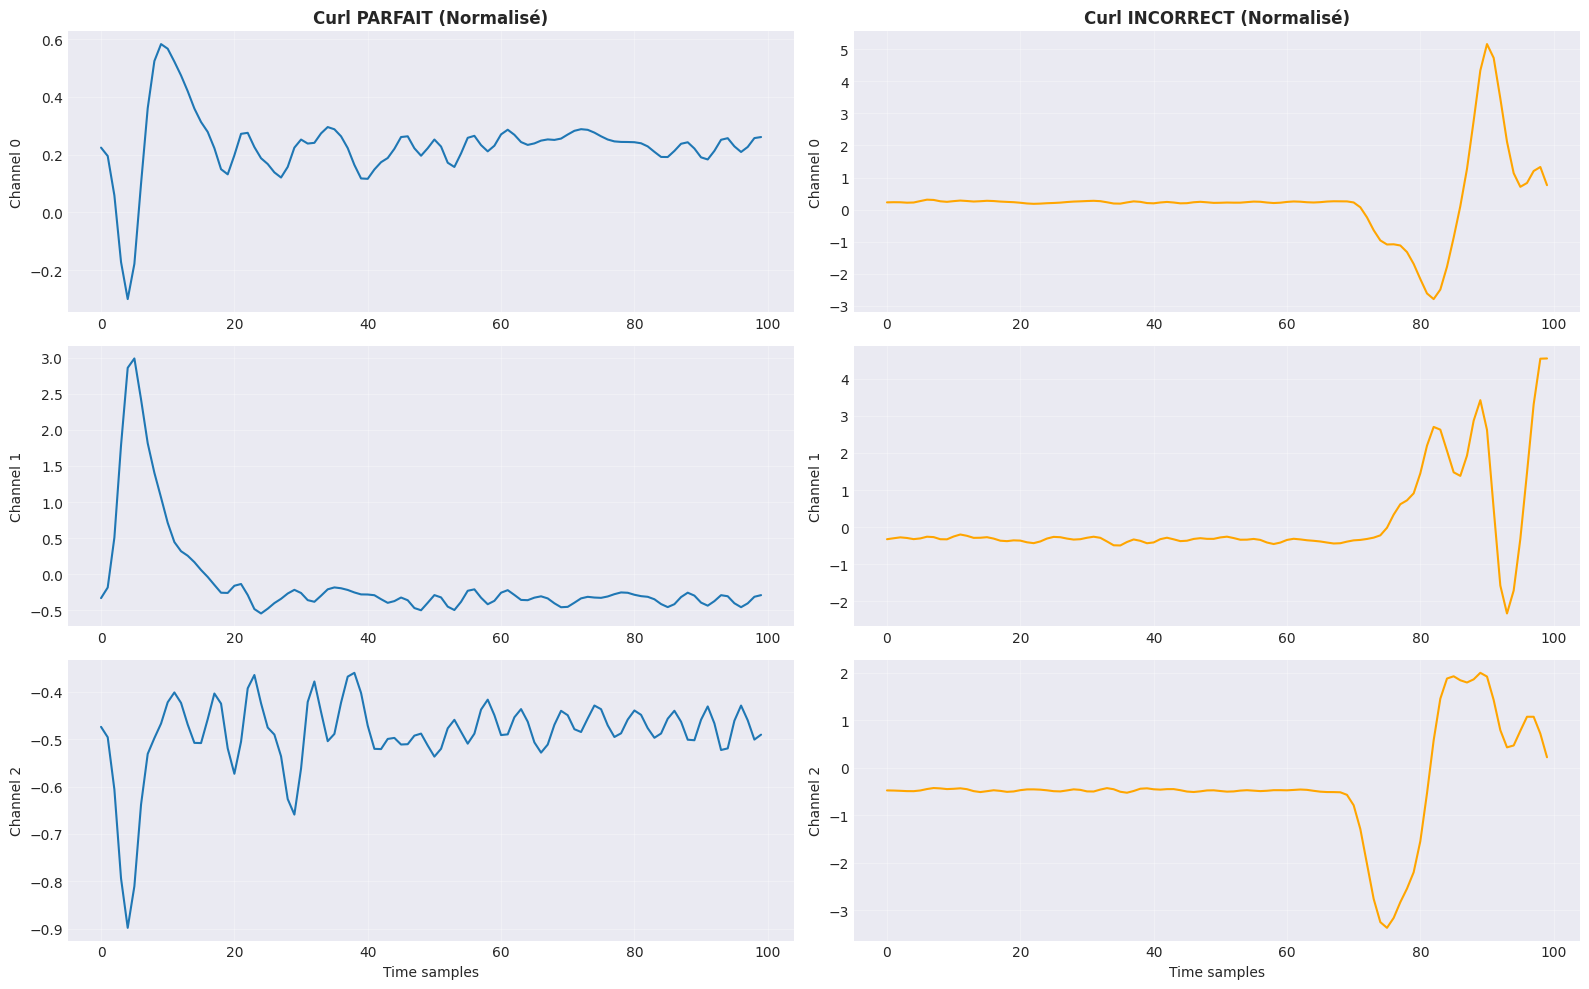

Perfect curl sample #0: shape (6, 100)
Imperfect curl sample #86: shape (6, 100)


In [7]:
idx_perfect = np.where(y == 1)[0][0]
idx_imperfect = np.where(y == 0)[0][0]

fig, axes = plt.subplots(3, 2, figsize=(16, 10))

# Accelerometer data (channels 0-2)
for i in range(3):
    # Perfect curl
    axes[i, 0].plot(X_normalized[idx_perfect, i, :], linewidth=1.5, label=f'Channel {i}')
    axes[i, 0].set_ylabel(f'Channel {i}', fontsize=10)
    axes[i, 0].grid(True, alpha=0.3)
    if i == 0:
        axes[i, 0].set_title('Curl PARFAIT (Normalisé)', fontsize=12, fontweight='bold')
    
    # Imperfect curl
    axes[i, 1].plot(X_normalized[idx_imperfect, i, :], linewidth=1.5, label=f'Channel {i}', color='orange')
    axes[i, 1].set_ylabel(f'Channel {i}', fontsize=10)
    axes[i, 1].grid(True, alpha=0.3)
    if i == 0:
        axes[i, 1].set_title('Curl INCORRECT (Normalisé)', fontsize=12, fontweight='bold')

axes[2, 0].set_xlabel('Time samples')
axes[2, 1].set_xlabel('Time samples')

plt.tight_layout()
plt.show()

print(f"Perfect curl sample #{idx_perfect}: shape {X_normalized[idx_perfect].shape}")
print(f"Imperfect curl sample #{idx_imperfect}: shape {X_normalized[idx_imperfect].shape}")

## 7. Distribution des données

Statistiques finales du dataset.

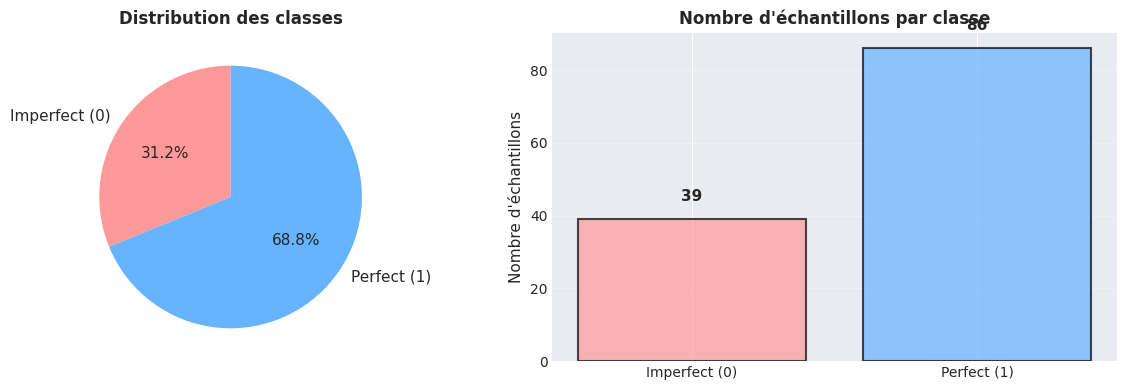


=== Résumé Final ===
Total échantillons: 125
  - Perfect (1): 86 (68.8%)
  - Imperfect (0): 39 (31.2%)

Dimensions finales: (125, 6, 100)
  - Batch size: 125
  - Channels: 6 (accel_x, accel_y, accel_z, gyro_x, gyro_y, gyro_z)
  - Sequence length: 100 (2.0 secondes à 50Hz)


In [8]:
perfect_count = np.sum(y == 1)
imperfect_count = np.sum(y == 0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Pie chart
labels = ['Imperfect (0)', 'Perfect (1)']
sizes = [imperfect_count, perfect_count]
colors = ['#ff9999', '#66b3ff']
ax1.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90, textprops={'fontsize': 11})
ax1.set_title('Distribution des classes', fontsize=12, fontweight='bold')

# Bar chart
ax2.bar(labels, sizes, color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
ax2.set_ylabel('Nombre d\'échantillons', fontsize=11)
ax2.set_title('Nombre d\'échantillons par classe', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

for i, (label, count) in enumerate(zip(labels, sizes)):
    ax2.text(i, count + 5, str(count), ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n=== Résumé Final ===")
print(f"Total échantillons: {len(X_normalized)}")
print(f"  - Perfect (1): {perfect_count} ({100*perfect_count/len(X_normalized):.1f}%)")
print(f"  - Imperfect (0): {imperfect_count} ({100*imperfect_count/len(X_normalized):.1f}%)")
print(f"\nDimensions finales: {X_normalized.shape}")
print(f"  - Batch size: {X_normalized.shape[0]}")
print(f"  - Channels: {X_normalized.shape[1]} (accel_x, accel_y, accel_z, gyro_x, gyro_y, gyro_z)")
print(f"  - Sequence length: {X_normalized.shape[2]} (2.0 secondes à 50Hz)")

## 8. Pipeline complet résumé

Documentation du pipeline de prétraitement.

## ============================================================
## PIPELINE DE PRÉTRAITEMENT - RÉSUMÉ COMPLET
## ============================================================

1. CHARGEMENT DES DONNÉES
   - Source: data/perfect/ et data/imperfect/
   - Accéléromètre: 3 axes (x, y, z)
   - Gyroscope: 3 axes (x, y, z)
   - Total: 6 canaux de données

2. FILTRAGE BUTTERWORTH LOW-PASS
   - Cutoff frequency: 10.0 Hz
   - Sampling frequency: 50.0 Hz
   - Order: 4
   - Objectif: Réduire le bruit haute fréquence

3. WINDOWING (FENÊTRAGE)
   - Window size: 100 samples
   - Step size: 50 samples
   - Duration per window: 2.00 secondes
   - Chevauchement: 50%

4. TRANSPOSITION
   - Format initial: (N, seq_len, channels)
   - Format final: (N, channels, seq_len)
   - Raison: Compatibilité PyTorch Conv1D

5. NORMALISATION
   - Type: Z-score (μ=0, σ=1)
   - Par canal indépendant
   - Epsilon: 1e-7 (pour éviter division par zéro)

## ============================================================
## RÉSULTAT FINAL: (125, 6, 100)
## Prêt pour l'entraînement du modèle CNN 1D!
## ============================================================